# Week 1 and 2: Importing the data and files

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
pattern = os.path.join(filepath, "CRMLSSold*.csv")
files = sorted(glob.glob(pattern))

# load and concatenate all files at once
df_list = [pd.read_csv(f, low_memory=False) for f in files]
data = pd.concat(df_list, ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Total rows: {len(data)}")
print(f"Columns: {data.shape[1]}")

Loaded 31 files
Total rows: 818778
Columns: 82


# Applying a data filter to fit the goal of the project

The goal of this project is to predict the close price of Single Family Homes which are also classified as Residential.

In [5]:
#applying data filter

filtered_data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')].copy()
print(filtered_data.shape)

(412015, 82)


# Performing manual visual inspection of the data to see what the distributions look like

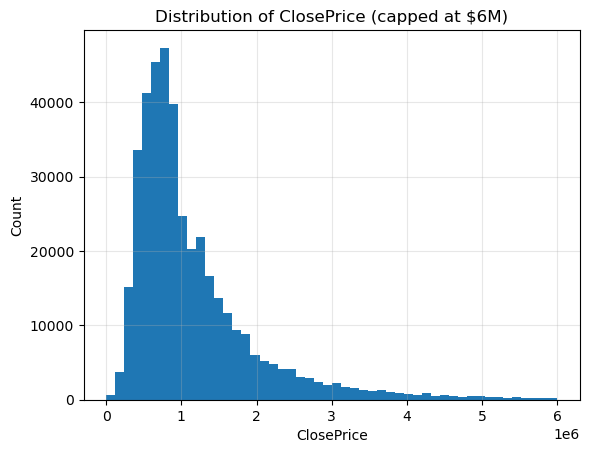

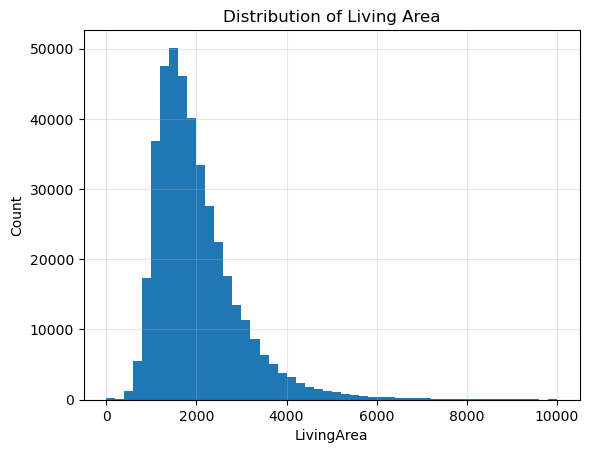

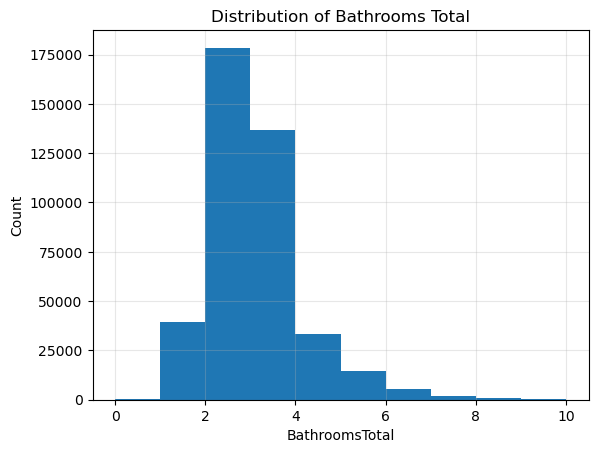

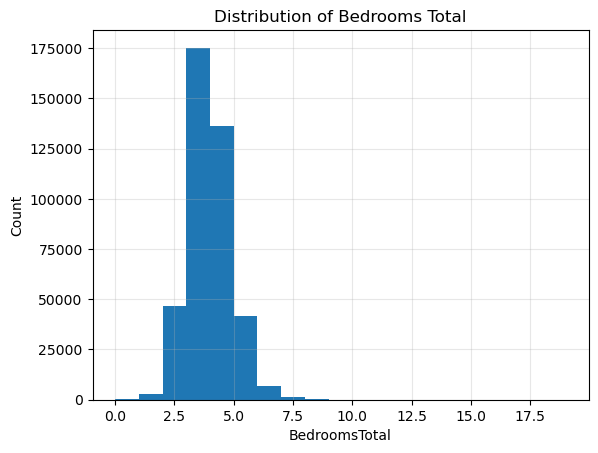

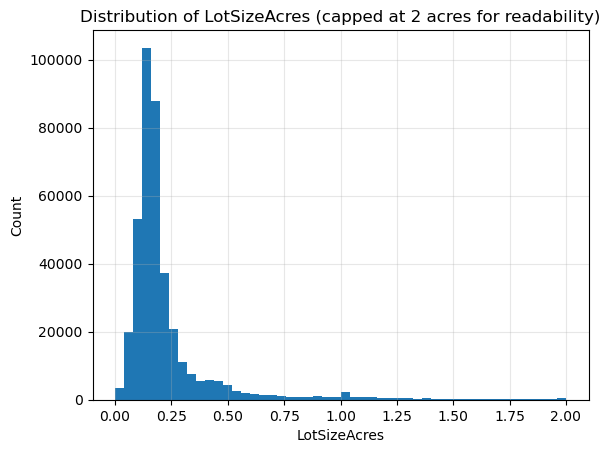

In [7]:
#histograms of data

# close price
filtered_data['ClosePrice'].hist(bins=50, range=(0, 6_000_000)) #capped price to make visualizaton better - some houses are way above average
plt.xlabel('ClosePrice')
plt.ylabel('Count')
plt.title('Distribution of ClosePrice (capped at $6M)')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# living area
filtered_data['LivingArea'].hist(bins=50, range=(0, 10000))
plt.xlabel('LivingArea')
plt.ylabel('Count')
plt.title('Distribution of Living Area')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bathrooms
filtered_data['BathroomsTotalInteger'].hist(range = (0, 10))
plt.xlabel('BathroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bathrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bedrooms
filtered_data['BedroomsTotal'].hist(bins=range(0, 20))
plt.xlabel('BedroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bedrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# lot size
filtered_data['LotSizeAcres'].hist(bins=50, range=(0, 2))
plt.xlabel('LotSizeAcres')
plt.ylabel('Count')
plt.title('Distribution of LotSizeAcres (capped at 2 acres for readability)')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Week 3: Data preprocessing, test/train split
The data ranges from January 2022 to May 2026. 

Previous to this step, we filter the data to single-family residential properties, because the end goal is to predict the closing price for this property type specifically. 

# Missing Value Handling
Below, we remove columns containing 100% missing values, as they will not provide useful information for modeling.

Additionally, we remove variables where there is more than 50% missing data, as imputing would introduce more synthetic values than real ones. For columns that remain, the data is imputed with the median value of the column where the column is numeric. The remaining categorial columns are imputed with the mode of the column.

# Data Type Conversion
Any date-related columns to datetime format to support time-based test/train splitting. Integer-like features (bedrooms, bathrooms, year built, stories, garage spaces, parking) are converted to integer format. PostalCode is converted to a string type as it represents a geographic label and is not truly a numeric quantity. GarageSpaces and ParkingTotal are converted from a float to an integer by rounding. Boolean columns are converted to binary integer representation (0/1). Finally, we drop coluns with only one unique value, as they are useless for modeling.

# Encoding
Below, one-hot encoding is applied to categorical columns with fewer than 15 unique values, which creates binary indicator columns for each category. Columns with more than 15 unique values (such as listing agent, etc.) are dropped due to their large number of unique values.

# Normalization
In this internship, we will later use linear regression, so normalization and scaling of the data is necessary because linear regression and other ML methods like GMM and Support Vectors are sensitive to feature scales. To perform normalization, continuous features were standardized using StandardScaler, which transforms each variable to have a mean of zero and have a standard deviation of one. This method ensures that features on different scales contribute equally to the model rather than allowing large-magnitude features to dominate.

# Test/Train split
Rather than splitting the data randomly, the most recent month of available data was reserved as the test set, which all earlier observations are used for training. 

In [9]:
# print starting columns
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412015 entries, 3 to 818775
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      264736 non-null  object 
 1   ViewYN                        371253 non-null  object 
 2   WaterfrontYN                  186 non-null     object 
 3   BasementYN                    10069 non-null   object 
 4   PoolPrivateYN                 370408 non-null  object 
 5   OriginalListPrice             411209 non-null  float64
 6   ListingKey                    412015 non-null  int64  
 7   ListAgentEmail                411137 non-null  object 
 8   CloseDate                     412015 non-null  object 
 9   ClosePrice                    412013 non-null  float64
 10  ListAgentFirstName            408515 non-null  object 
 11  ListAgentLastName             411978 non-null  object 
 12  Latitude                      411822 non-null  fl

In [11]:
# remove columns with 100 % missing data
data_clean = filtered_data.dropna(axis=1, how="all")
print(f"Columns remaining after 100% drop: {data_clean.shape[1]}")

Columns remaining after 100% drop: 74


In [12]:
# removing columns with more than 50% missing
threshold = 0.5
data_clean = data_clean.loc[:, data_clean.isnull().mean() < threshold]
print(f"Columns remaining after 50% drop: {data_clean.shape[1]}")

Columns remaining after 50% drop: 55


In [13]:
# imputing remaining missing values
for col in data_clean.columns:
    if data_clean[col].dtype in ['float64', 'int64']:
        # where numeric -> impute with median
        data_clean[col].fillna(data_clean[col].median(), inplace=True)
    else:
        # where categorical impute with mode
        data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)


C:\Users\julia\AppData\Local\Temp\ipykernel_7180\2943490563.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)
C:\Users\julia\AppData\Local\Temp\ipykernel_7180\2943490563.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_clean[col].fillna(d

In [12]:
# converting date columns to datetime
date_cols = ['CloseDate', 'ListingContractDate', 
             'ContractStatusChangeDate', 'PurchaseContractDate']
for col in date_cols:
    if col in data_clean.columns:
        data_clean[col] = pd.to_datetime(data_clean[col], errors='coerce')

In [13]:
# converting integer-like features to integer format
int_cols = ['BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 
            'Stories', 'MainLevelBedrooms', 'GarageSpaces', 'ParkingTotal']

for col in int_cols:
    if col in data_clean.columns:
        data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce').round().astype('Int64')

print(data_clean[int_cols].dtypes)

BedroomsTotal            Int64
BathroomsTotalInteger    Int64
YearBuilt                Int64
Stories                  Int64
MainLevelBedrooms        Int64
GarageSpaces             Int64
ParkingTotal             Int64
dtype: object


In [14]:
# dropping columns that are redundant with lat/long
data_clean = data_clean.drop(columns=['Flooring', 'City', 'CountyOrParish', 'MLSAreaMajor', 'PostalCode', 'ListAgentAOR', 
                      'ContractStatusChangeDate', 'ListingContractDate', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListingKey'])

In [15]:
#print(data_clean.head())

## Removing redundant variables and dropping rows where the data does not make sense, ex: homes built in the 1800's and living area that does not make sense

In [17]:
# Remove invalid observations
initial_count = len(data_clean)

# invalid ClosePrice
data_clean = data_clean[data_clean['ClosePrice'] > 0]
data_clean = data_clean.dropna(subset=['ClosePrice'])

# unrealistic ClosePrice range
data_clean = data_clean[
    (data_clean['ClosePrice'] >= 50000) & 
    (data_clean['ClosePrice'] <= 10000000)
]

# invalid living area
data_clean = data_clean[
    (data_clean['LivingArea'] >= 200) & 
    (data_clean['LivingArea'] <= 15000)
]

# invalid bedroom/bathroom counts
data_clean = data_clean[
    (data_clean['BedroomsTotal'] > 0) & 
    (data_clean['BedroomsTotal'] <= 15) &
    (data_clean['BathroomsTotalInteger'] > 0) & 
    (data_clean['BathroomsTotalInteger'] <= 15)
]

# logical impossibility: too many bedrooms for living area
data_clean = data_clean[
    ~((data_clean['BedroomsTotal'] >= 5) & 
      (data_clean['LivingArea'] < 800))
]

# invalid year built
data_clean = data_clean[
    (data_clean['YearBuilt'] >= 1800) & 
    (data_clean['YearBuilt'] <= 2026)
]

# duplicate transactions - using specific combination to avoid removing legitimate sales
data_clean = data_clean.drop_duplicates(
    subset=['CloseDate', 'ClosePrice', 'LivingArea', 'BedroomsTotal', 'Latitude', 'Longitude']
)

# summary
removed = initial_count - len(data_clean)
print(f"Rows removed: {removed:,} ({removed / initial_count * 100:.2f}%)")
print(f"Remaining rows: {len(data_clean):,}")

Rows removed: 2,015 (0.50%)
Remaining rows: 397,142


In [18]:
# Converting Boolean to binary
bool_cols = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

for col in bool_cols:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(int)

print(data_clean[bool_cols].dtypes)

ViewYN               int32
PoolPrivateYN        int32
AttachedGarageYN     int32
FireplaceYN          int32
NewConstructionYN    int32
dtype: object


In [19]:
# drop columns with only 1 unique value, dropping columns with non-useful object columns
single_value_cols = [col for col in data_clean.columns 
                     if data_clean[col].nunique() == 1]
print(f"Dropping single value columns: {single_value_cols}")
data_clean = data_clean.drop(columns=single_value_cols)

# drop high cardinality and non-useful object columns
drop_cols = [
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'ListAgentFullName', 'ListOfficeName', 'BuyerOfficeName',
    'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
    'UnparsedAddress', 'ListingId', 'Flooring', 'MLSAreaMajor', 
    'ContractStatusChangeDate', 'PurchaseContractDate', 
    'ListingContractDate'
]
drop_cols = [c for c in drop_cols if c in data_clean.columns]
data_clean = data_clean.drop(columns=drop_cols)
print(f"Shape after dropping: {data_clean.shape}")

Dropping single value columns: ['PropertyType', 'MlsStatus', 'PropertySubType']
Shape after dropping: (397142, 29)


In [20]:
# checking remaining columns before encoding
obj_cols = data_clean.select_dtypes(include='object').columns
for col in obj_cols:
    print(f"{col}: {data_clean[col].nunique()} unique values")\

data_clean.drop(columns='HighSchoolDistrict')
print(data_clean.columns)

StateOrProvince: 13 unique values
Levels: 17 unique values
HighSchoolDistrict: 446 unique values
Index(['ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListingKeyNumeric', 'AttachedGarageYN', 'ParkingTotal',
       'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'BedroomsTotal', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'LotSizeSquareFeet'],
      dtype='object')


In [21]:
# converting impossible coordinates to NaNs
invalid_coords = (
    (data_clean['Latitude'] < -90) | (data_clean['Latitude'] > 90) |
    (data_clean['Longitude'] < -180) | (data_clean['Longitude'] > 180) |
    (data_clean['Latitude'] == 0) | (data_clean['Longitude'] == 0)
)
data_clean.loc[invalid_coords, ['Latitude', 'Longitude']] = np.nan

# then drop rows with missing coordinates
data_clean = data_clean.dropna(subset=['Latitude', 'Longitude'])

In [22]:
print(len(data_clean.columns))
print("PostalCode" in data_clean)

29
False


In [23]:
# one hot encoding

# Select categorical columns to encode
ohe_cols = [
    col for col in data_clean.select_dtypes(include="object").columns
    if data_clean[col].nunique() < 100
]
# Standardize categories
for col in ohe_cols:
    data_clean[col] = (
        data_clean[col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# One-hot encode
data_clean = pd.get_dummies(
    data_clean,
    columns=ohe_cols,
    drop_first=True
)

print(data_clean.shape)

(397103, 55)


In [63]:
def make_train_test_split(df, date_col='CloseDate', x_months=12):
    """
    Creates a time-based train/test split.
    
    Parameters:
        df: cleaned dataframe
        date_col: name of the date column to split on
        x_months: number of months to use for training window (tunable)
    
    Returns:
        train_df, test_df
    """
    df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    
    latest_month = df[date_col].dt.to_period('M').max()
    cutoff_month = latest_month - x_months
    
    test_df = df[df[date_col].dt.to_period('M') == latest_month].copy()
    train_df = df[
        (df[date_col].dt.to_period('M') > cutoff_month) &
        (df[date_col].dt.to_period('M') < latest_month)
    ].copy()
    
    print(f"Test month: {latest_month}")
    print(f"Training window: {x_months} months ({cutoff_month} to {latest_month})")
    print(f"Training rows: {len(train_df):,}")
    print(f"Testing rows:  {len(test_df):,}")
    
    return train_df, test_df

# run with default 12 months to start
train_df, test_df = make_train_test_split(data_clean, x_months=30)

'''
# try different training windows and compare
for x in [6, 12, 18, 24]:
    train_df, test_df = make_train_test_split(data_clean, x_months=x)
    print()
''';

Test month: 2026-05
Training window: 30 months (2023-11 to 2026-05)
Training rows: 316,377
Testing rows:  11,957


## Outlier Removal using training thresholds

In order to remove data entry errors and extreme outliers, outlier thresholds are computed using the training set only and then applied as cutoffs to both training and test datasets. This is applied to ClosePrice filtering below the 0.5th percentile and above the 99.5th percentile. Additionally, this is applied to price-per-square-foot 

In [66]:
# outlier removal using training thresholds

# Remove extreme ClosePrice outliers
# thresholds learned from training data only

# compute thresholds from training set only
lower_limit = train_df["ClosePrice"].quantile(0.005)
upper_limit = train_df["ClosePrice"].quantile(0.995)

print(f"Lower limit (0.5th percentile): ${lower_limit:,.0f}")
print(f"Upper limit (99.5th percentile): ${upper_limit:,.0f}")

# apply same thresholds to both sets
before_train = len(train_df)
before_test = len(test_df)

train_df = train_df[
    (train_df["ClosePrice"] >= lower_limit) &
    (train_df["ClosePrice"] <= upper_limit)
]

test_df = test_df[
    (test_df["ClosePrice"] >= lower_limit) &
    (test_df["ClosePrice"] <= upper_limit)
]

print(f"Train removed: {before_train - len(train_df):,} rows")
print(f"Test removed: {before_test - len(test_df):,} rows")
print(f"Train remaining: {len(train_df):,}")
print(f"Test remaining: {len(test_df):,}")


Lower limit (0.5th percentile): $195,000
Upper limit (99.5th percentile): $6,700,000
Train removed: 3,089 rows
Test removed: 113 rows
Train remaining: 313,288
Test remaining: 11,844


# Using standard scaler to normalize the data before linear regression is performed next week

Fit transform is applied on the training set and transorm only on test -> the scaler learns the mean and std dev from the training data only then applied the values to the test set. This prevents leaks into the distribution of scaling information.

In [68]:
from sklearn.preprocessing import StandardScaler

continuous_columns = [
    "Latitude", "Longitude", "LivingArea", "DaysOnMarket",
    "ParkingTotal", "LotSizeAcres", "YearBuilt",
    "StreetNumberNumeric", "BathroomsTotalInteger",
    "BedroomsTotal", "Stories", "LotSizeArea",
    "MainLevelBedrooms", "GarageSpaces",
    "AssociationFee", "LotSizeSquareFeet"
]

# Only use columns that still exist
continuous_columns = [
    col for col in continuous_columns
    if col in train_df.columns
]

scaler = StandardScaler()

train_df[continuous_columns] = scaler.fit_transform(
    train_df[continuous_columns]
)

test_df[continuous_columns] = scaler.transform(
    test_df[continuous_columns]
)

print(f"Scaled {len(continuous_columns)} continuous features.")

Scaled 16 continuous features.


In [69]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(
    "Remaining object columns:",
    train_df.select_dtypes(include="object").columns.tolist()
)

print(
    "Postal code columns present:",
    any(col.startswith("PostalCode") for col in train_df.columns)
)

Train shape: (313288, 55)
Test shape: (11844, 55)
Remaining object columns: ['HighSchoolDistrict']
Postal code columns present: False


In [72]:
# export cleaned train/test splits
train_df.to_csv(filepath + r"\train_cleaned.csv", index=False)
test_df.to_csv(filepath + r"\test_cleaned.csv", index=False)

print(f"train_cleaned.csv saved — {len(train_df):,} rows")
print(f"test_cleaned.csv saved — {len(test_df):,} rows")

train_cleaned.csv saved — 313,288 rows
test_cleaned.csv saved — 11,844 rows


Final Dataset Summary

Training observations: 116,398
Testing observations: 11,851
Features after preprocessing: 1,446

Preprocessing steps:
- Missing value handling
- High-cardinality feature removal
- One-hot encoding of categorical variables
- Outlier removal (99.5th percentile ClosePrice cutoff)
- Feature scaling using StandardScaler
- Time-based train/test split

In [81]:
print("done")
print(data_clean.columns)

done
Index(['ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListingKeyNumeric', 'AttachedGarageYN', 'ParkingTotal',
       'LotSizeAcres', 'YearBuilt', 'StreetNumberNumeric',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'AssociationFee', 'LotSizeSquareFeet',
       'StateOrProvince_BC', 'StateOrProvince_CA', 'StateOrProvince_CO',
       'StateOrProvince_FL', 'StateOrProvince_GA', 'StateOrProvince_ME',
       'StateOrProvince_MO', 'StateOrProvince_NV', 'StateOrProvince_NY',
       'StateOrProvince_OS', 'StateOrProvince_TN', 'StateOrProvince_TX',
       'Levels_MULTISPLIT,ONE', 'Levels_ONE', 'Levels_ONE,MULTISPLIT',
       'Levels_ONE,THREEORMORE', 'Levels_ONE,TWO', 'Levels_ONE,TWO,MULTISPLIT',
       'Levels_ONE,TWO,THREEORMORE', 'Levels_ONE,